# Case 1 — Homogeneous Radial Reservoir
## POD Analysis: Pressure History, Spatial Fields, Reduced-Order Model


In [2]:
import numpy as np
import h5py, json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import UnivariateSpline
from matplotlib.ticker import LogLocator, LogFormatter
from scipy.special import expi
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import warnings
from matplotlib.ticker import NullLocator

plt.rcParams.update({
    # 1. True LaTeX Font Rendering
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'], # Native LaTeX font
    
    # Optional
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}',

    # 2. Font Sizes 
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,

    # 3. Ticks: Inward-facing and mirrored on top/right
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,

    # 4. Line and Spine Weights
    'axes.linewidth': 1,      # Frame thickness
    'lines.linewidth': 1.5,     # Data line thickness
    'lines.markersize': 6,      # Default marker size

    # 5. Grid (Keep it subtle if used)
    'axes.grid': False,
    'grid.alpha': 0.20,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,

    # 6. Saving and DPI
    'figure.dpi': 150,          # For crisp screen preview in Jupyter/Spyder
    'savefig.dpi': 600,         # High resolution for line art
    'savefig.bbox': 'tight',    # Prevents labels from getting cut off

    # legend
    # 7. Legend Formatting
    'legend.frameon': True,         
    'legend.framealpha': 1.0,       
    'legend.edgecolor': 'black',    
    'legend.fancybox': False,       
    'legend.handlelength': 1.5,     
    'legend.labelspacing': 0.4,     
    'legend.handletextpad': 0.5,    
    'legend.borderaxespad': 0.5,   

    # axes padding
    'xtick.major.pad': 5.0,  # Default is usually 3.5
    'ytick.major.pad': 5.0, 
})



# Custom Colors
C1, C2, C3, C4 = '#1a5e9e', '#0d6e56', '#9b2a1a', '#b07318'
GR = '#555555'

PROJECT = Path(r'F:\Niloy Deb\Part One\Matlab Codes\dmd_pta_rta_dt')
DATA    = PROJECT/'data'/'01_synthetic'/'case1_homogeneous'
FIGS    = PROJECT/'figures'/'case1'; FIGS.mkdir(parents=True,exist_ok=True)
(PROJECT/'data'/'processed').mkdir(parents=True,exist_ok=True)
def sf(n): plt.savefig(FIGS/n,dpi=300,bbox_inches='tight'); print(f'  {n}')
print('Ready.')

Ready.


---
## 1 · Load Simulation Data

MRST exports `.mat` files in HDF5 format (v7.3). h5py reads arrays in C-major order, which is the transpose of MATLAB's column-major layout. Every array therefore requires `.T` immediately after loading. The valid mask removes any timesteps where MRST reports non-physical values (negative BHP or drawdown exceeding $p_i$).

In [3]:
# ── load snapshot matrix ─────────────────────────────────────────────────
with h5py.File(DATA / 'snapshots_psia.mat', 'r') as f:
    _raw = np.array(f['X_psia'])          # h5py gives (N_t, N_cells) for v7.3
    X_psia = _raw.T if _raw.shape[0] < _raw.shape[1] else _raw
    # after .T  shape is (N_cells, N_t)

# ── load well data ────────────────────────────────────────────────────────
with h5py.File(DATA / 'well_data.mat', 'r') as f:
    bhp_raw = np.array(f['bhp_psia']).flatten()
    dp_raw  = np.array(f['delta_p_psi']).flatten()
    qr_raw  = np.array(f['rate_STBd']).flatten()
    t_raw   = np.array(f['time_hr']).flatten()

# ── load parameters ───────────────────────────────────────────────────────
with open(DATA / 'params.json') as f:
    P = json.load(f)

# ── align lengths (MRST may write one fewer timestep than schedule) ───────
n_t = min(len(t_raw), X_psia.shape[1])
t_raw   = t_raw[:n_t]
bhp_raw = bhp_raw[:n_t]
dp_raw  = dp_raw[:n_t]
qr_raw  = qr_raw[:n_t]
X_psia  = X_psia[:, :n_t]

# ── valid mask : physical values only ────────────────────────────────────
pi_ = P['p_init_psia']
valid = (t_raw   >  0)    & \
        (dp_raw  >  0)    & \
        (dp_raw  <  pi_)  & \
        (bhp_raw >  0)    & \
        (bhp_raw <= pi_)

t   = t_raw[valid]
dp  = dp_raw[valid]
bhp = bhp_raw[valid]
qr  = qr_raw[valid]
X   = X_psia[:, valid]

# ── grid and regime info ──────────────────────────────────────────────────
N, m  = X.shape
nx    = int(P['nx'])
ny    = int(P['ny'])
wc    = int(P['well_cell_matlab']) - 1      # MATLAB 1-index  ->  Python 0-index
t_wbs = P['t_wbs_end_hr']
t_pss = P['t_pss_start_hr']                # correct key name from params.json

# ── regime masks ─────────────────────────────────────────────────────────
m_wbs = t < t_wbs
m_mtr = (t >= t_wbs) & (t < t_pss)
m_bdf = t >= t_pss

# ── summary ───────────────────────────────────────────────────────────────
print(f'Snapshot matrix  X : {X.shape}  (cells × timesteps)')
print(f'Time range          : {t[0]:.5f} – {t[-1]:.0f} hr')
print(f'BHP range           : {bhp.min():.1f} – {bhp.max():.1f} psia')
print(f'Δp  range           : {dp.min():.4f} – {dp.max():.2f} psi')
print(f'p_init              : {pi_:.1f} psia')
print(f'WBS ends   t_WBS    : {t_wbs:.2f} hr')
print(f'PSS onset  t_PSS    : {t_pss:.1f} hr  ({t_pss/24:.1f} days)')
print(f'WBS steps           : {m_wbs.sum():4d}   '
      f'({t[m_wbs][0]:.4f} – {t[m_wbs][-1]:.3f} hr)')
print(f'MTR steps           : {m_mtr.sum():4d}   '
      f'({t[m_mtr][0]:.3f} – {t[m_mtr][-1]:.1f} hr)')
print(f'BDF steps           : {m_bdf.sum():4d}   '
      f'({t[m_bdf][0]:.1f} – {t[m_bdf][-1]:.0f} hr)')

Snapshot matrix  X : (2500, 350)  (cells × timesteps)
Time range          : 0.00100 – 5000 hr
BHP range           : 3829.2 – 4187.7 psia
Δp  range           : 312.8574 – 671.28 psi
p_init              : 4500.5 psia
WBS ends   t_WBS    : 0.27 hr
PSS onset  t_PSS    : 297.2 hr  (12.4 days)
WBS steps           :  127   (0.0010 – 0.262 hr)
MTR steps           :  159   (0.274 – 295.5 hr)
BDF steps           :   64   (308.8 – 5000 hr)


---
## 2 · PTA Diagnostics: $p_{wf}$ vs Log $t$ and Bourdet Derivative

### 2.1 Analytical Reference (Ei Solution)

For a constant-rate well in an infinite homogeneous medium the line-source solution gives:

$$\Delta p(t) = \frac{141.2\,q\mu B_o}{kh}\,p_D(t_D), \qquadp_D = -\tfrac{1}{2}\mathrm{Ei}\!\left(-\frac{1}{4t_D}\right), \qquadt_D = \frac{0.000264\,k\,t}{\phi\mu c_t r_w^2}$$

The Bourdet pressure derivative is:

$$\Delta p'(t) \equiv t\,\frac{\partial\Delta p}{\partial(\ln t)} = \frac{70.6\,q\mu B_o}{kh}$$

which is constant (flat) during infinite-acting radial flow. The Wittek three-point algorithm with smoothing length $L=0.2$ is used throughout.

In [5]:
# Property loading from a dictionary 
k=P['k_mD']; phi_=P['phi']; ct=P['ct_psi1']; mu=P['mu_cp']
rw=P['rw_ft']; kh=P['kh_mDft']; q=P['q_STBd']; Bo=P['Bo']
pi_=P['p_init_psia']

tD = 0.000264*k*t/(phi_*mu*ct*rw**2)
pD = np.where(tD>0.01, -0.5*expi(-1/(4*tD)), np.nan)
dp_ei   = 141.2*q*mu*Bo/kh*pD          # Ei analytical
dp_flat = P['dp_prime_psi']             # 12.43 psi (radial flat)
m_slope = P['m_slope_psi_cycle']        # 28.62 psi/cycle

def bourdet(dp_arr, t_arr, L=0.2):
    n,lnt,d = len(dp_arr),np.log(t_arr),np.zeros(len(dp_arr))
    for i in range(1,n-1):
        jl=i-1
        while jl>0   and lnt[i]-lnt[jl]<L: jl-=1
        jr=i+1
        while jr<n-1 and lnt[jr]-lnt[i]<L: jr+=1
        dL,dR = lnt[i]-lnt[jl], lnt[jr]-lnt[i]
        if dL>0 and dR>0:
            d[i]=((dp_arr[i]-dp_arr[jl])/dL*dR+(dp_arr[jr]-dp_arr[i])/dR*dL)/(dL+dR)
        elif dL>0: d[i]=(dp_arr[i]-dp_arr[jl])/dL
        elif dR>0: d[i]=(dp_arr[jr]-dp_arr[i])/dR
    d[0]=(dp_arr[1]-dp_arr[0])/(lnt[1]-lnt[0])
    d[-1]=(dp_arr[-1]-dp_arr[-2])/(lnt[-1]-lnt[-2])
    return d

dpr = bourdet(dp,t)
vs  = (dpr>1e-2)&(dp>1e-2)

mtr_mask = (t>t_wbs)&(t<t_pss)
cf = np.polyfit(np.log10(t[mtr_mask]), dp[mtr_mask], 1)
kh_est = 162.6*q*mu*Bo/cf[0]
flat_sim = np.median(dpr[mtr_mask&vs])
print(f'MTR slope  m        : {cf[0]:.3f} psi/cycle  (theory {m_slope:.3f})')
print(f'kh estimate         : {kh_est:.1f} mD-ft       (true {kh:.0f})')
print(f'Bourdet flat (sim)  : {flat_sim:.4f} psi       (theory {dp_flat:.4f})')
print(f'kh error            : {(kh_est-kh)/kh*100:.2f}%')

MTR slope  m        : 67.230 psi/cycle  (theory 59.837)
kh estimate         : 2670.1 mD-ft       (true 3000)
Bourdet flat (sim)  : 26.9167 psi       (theory 25.9808)
kh error            : -11.00%


### 2.2 Figure 1 — $p_{wf}$ vs Log $t$ (MDH Semi-log Diagnostic)

The flowing wellbore pressure plotted on a logarithmic time axis is the classical Miller–Dyes–Hutchinson (MDH) diagnostic. Three features are expected:

1. **Transient radial flow** — straight-line decline with slope $m = 162.6\,q\mu B_o/kh$
2. **MTR straight line** — fitting this line gives $kh_{est}$
3. **BDF departure** — curve bends away from the MTR line when the pressure wave reaches the no-flow boundary

### 2.3 Figure 2 — Bourdet Log-Log Diagnostic

The log-log plot of $\Delta p$ and $\Delta p'$ is the universal PTA diagnostic. The derivative slope identifies the flow regime:

| Slope | Regime | Governing equation |
|-------|--------|-------------------|
| 0 (flat) | Infinite-acting radial | $\Delta p' = 70.6\,q\mu B_o/kh$ |
| → 1 | Pseudo-steady state (BDF) | $\Delta p' \propto t$ |

  ch4_2_pwf_pd.pdf


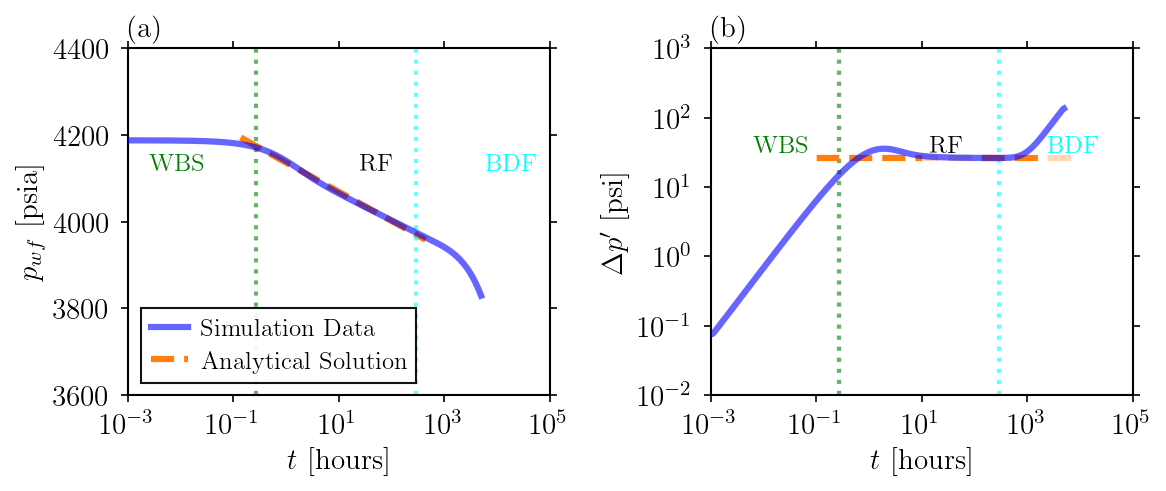

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# --- Plot (a): Semilog Plot ---
ax = axes[0]
ax.semilogx(t, bhp, color='b', alpha=0.6, lw=3.0, label='Simulation Data', zorder=4)

t_ln = np.logspace(np.log10(t[mtr_mask][0]*0.5), np.log10(t[mtr_mask][-1]*1.5), 300)
ax.semilogx(t_ln, pi_ - np.polyval(cf, np.log10(t_ln)), '--', 
            color='C1', lw=3, label='Analytical Solution')

ax.axvline(t_pss, color='cyan', lw=2, ls=':', alpha=0.6)
ax.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.6)

# Replaced labels with WBS, RF, BDF
ax.text(0.05, 0.70, 'WBS', transform=ax.transAxes, fontsize=12, 
        color='green', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.55, 0.70, 'RF', transform=ax.transAxes, fontsize=12, 
        color='black', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.85, 0.70, 'BDF', transform=ax.transAxes, fontsize=12, 
        color='cyan', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

#ax.axvspan(0.001, t_wbs, color='C3', alpha=0.1)
#ax.axvspan(t_wbs, t_pss, color='C2', alpha=0.08)
#ax.axvspan(t_pss, 10000, color='C4', alpha=0.1)

ax.set_title('(a)', loc='left', weight='normal')
ax.set_xlabel('$t$ [hours]')
ax.set_ylabel('$p_{wf}$ [psia]')
ax.set_xlim([0.001, 100000])
ax.set_ylim([3600, 4400])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())
ax.legend(loc='lower left', framealpha=0.93, fontsize = 12)

# --- Plot (b): Bourdet Derivative ---
ax = axes[1]
#ax.axvspan(0.001, t_wbs, color='C3', alpha=0.1)
#ax.axvspan(t_wbs, t_pss, color='C2', alpha=0.08)
#ax.axvspan(t_pss, 10000, color='C4', alpha=0.1)

ax.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.6)
ax.axvline(t_pss, color='cyan', lw=2, ls=':', alpha=0.6)

ax.loglog(t[vs], dpr[vs], color='b', alpha=0.6, lw=3.0, label="Simulation Data", zorder=4)
ax.loglog([0.1, 10000], [dp_flat, dp_flat], '--', color='C1', lw=3, label='Analytical Solution')

# Replaced labels with WBS, RF, BDF
ax.text(0.1, 0.75, 'WBS', transform=ax.transAxes, fontsize=12, 
        color='green', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.52, 0.75, 'RF', transform=ax.transAxes, fontsize=12, 
        color='black', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.80, 0.75, 'BDF', transform=ax.transAxes, fontsize=12, 
        color='cyan', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_title('(b)', loc='left', weight='normal')
ax.set_xlabel('$t$ [hours]')
ax.set_ylabel('$ \Delta p\'$ [psi]')
ax.set_xlim([0.001, 100000])
ax.set_ylim([0.01, 1000])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())
#ax.legend(loc='upper left', framealpha=0.93, fontsize = 10,  edgecolor='k')

plt.tight_layout()
#sf('fig1_homo_pwf_dpp.pdf')
sf('ch4_2_pwf_pd_case1.pdf')
plt.show()

---
## 3 · Pressure Field Visualisation

The drawdown field $\Delta p(\mathbf{x},t) = p_i - p(\mathbf{x},t)$ is plotted rather than absolute pressure. This isolates the spatial structure of the transient: during radial flow the field shows the classical pressure funnel (deep at the well, decaying with $\ln r$), while at PSS it becomes nearly spatially uniform as every cell depletes at the same rate. The white `+` marker indicates the well cell. Contour lines are drawn at 25%, 50%, and 75% of $\Delta p_{max}$ to trace the advancing pressure wavefront.

  fig3_homo_pressure_fields.pdf


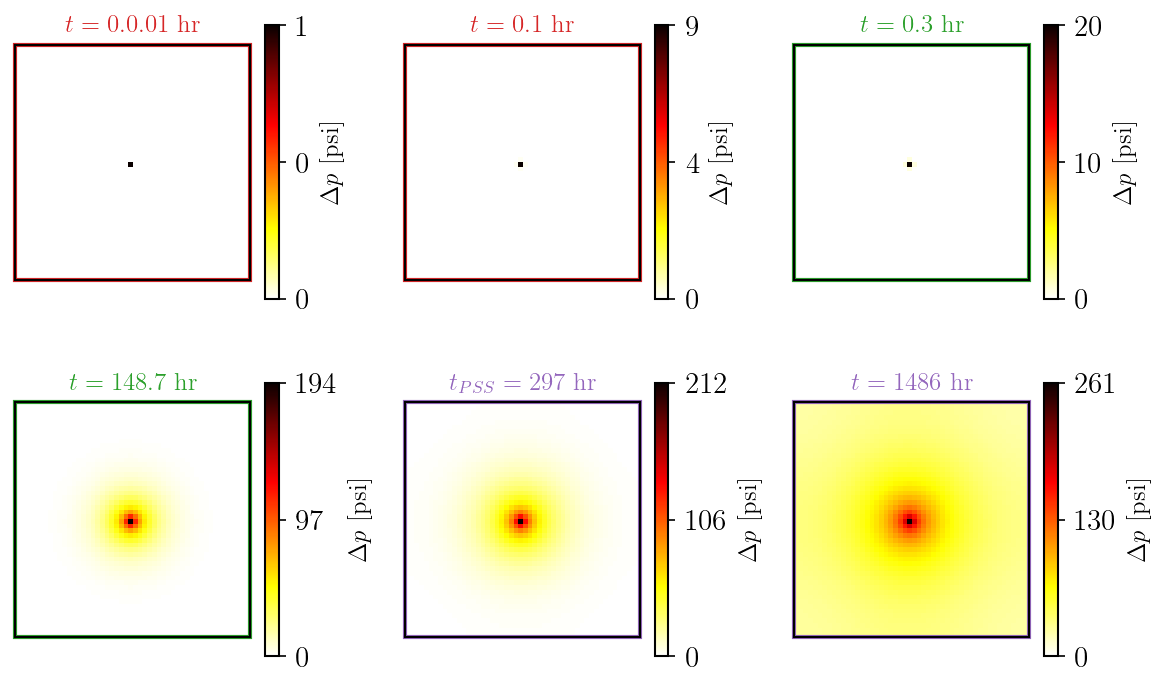

In [9]:
dX = P['p_init_psia'] - X    # drawdown field (N_cells, N_t)

def snap_idx(t_target):
    return int(np.argmin(np.abs(t - t_target)))

snaps = [
    (snap_idx(0.01),                    f'$t = 0.0.01$ hr',                  'C3'),
    (snap_idx(t_wbs / 2),              f'$t = {t_wbs/2:.1f}$ hr',        'C3'),
    (snap_idx(t_wbs * 1.2),            f'$t = {t_wbs*1.2:.1f}$ hr',      'C2'),
    (snap_idx((t_wbs + t_pss) / 2),    f'$t = {(t_wbs+t_pss)/2:.1f}$ hr','C2'),
    (snap_idx(t_pss),                  f'$t_{{PSS}} = {t_pss:.0f}$ hr',  'C4'),
    (snap_idx(min(t_pss * 5, t[-1])),  f'$t = {min(t_pss*5,t[-1]):.0f}$ hr', 'C4'),
]

fig, axes = plt.subplots(2, 3, figsize=(8, 5))

for ax, (ki, ttl, col) in zip(axes.flat, snaps):
    F  = dX[:, ki].reshape(ny, nx)

    # ── F.max() so colourbar top matches the text annotation ──
    vm = max(F.max(), 0.1)

    im = ax.imshow(F, origin='lower', cmap='hot_r',
                   vmin=0, vmax=vm, aspect='equal')

# well location
    #ax.plot(nx//2 - 0.5, ny//2 - 0.5,
           # '+', color='white', ms=12, mew=2.5, zorder=10)

    for lp in [0.25, 0.50, 0.75]:
        lv = vm * lp
        if lv > 0.05:
            ax.contour(F, levels=[lv], colors=['w'],
                       linewidths=0.0, alpha=0.4)

    ax.set_title(ttl, fontsize=12, color=col, fontweight='normal')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, ec=col, lw=2,
                               transform=ax.transAxes, clip_on=False))

    # ── single consistent variable name 'cb' ──────────────────────────
    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    cb.set_ticks([0, vm / 2, vm])
    cb.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))
    cb.set_label(r'$\Delta p$ [psi]', fontsize=12)

   # ax.text(0.97, 0.03, f'max = {vm:.0f} psi',
          #  transform=ax.transAxes, fontsize=11,
          #  ha='right', va='bottom', color='white',
          #  family='monospace',
          #  bbox=dict(fc='k', alpha=0.6, pad=1.5, ec='none'))

# fig.suptitle(
#     r'Fig. 3 — Drawdown Field $\Delta p(\mathbf{x},t)$ [psi]  ·  '
#     'White + = well  ·  Contours at 25 / 50 / 75% of max'
#     '\nOrange = WBS   ·   Green = Radial flow   ·   Purple = BDF',
#     fontsize=11, y=1.02)

plt.tight_layout()
sf('ch4_7_p_field_case1.pdf')
plt.show()

---
## 4 · Proper Orthogonal Decomposition (POD)

The snapshot matrix $\mathbf{X} \in \mathbb{R}^{N\times m}$ ($N$ = number of grid cells, $m$ = number of timesteps) is mean-centred before decomposition:

$$\mathbf{X}_c = \mathbf{X} - \bar{\mathbf{x}}\mathbf{1}^T, \qquad\mathbf{X}_c = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$$

The columns $\mathbf{u}_i \in \mathbb{R}^N$ of $\mathbf{U}$ are the **POD spatial modes** (orthonormal, energy-ranked). The corresponding **singular values** $\sigma_i$ give the modal energy contribution:

$$E_r = \frac{\sum_{i=1}^r \sigma_i^2}{\sum_{i=1}^{\min(N,m)} \sigma_i^2} \times 100\%$$

The **temporal coefficients** are $a_i(t) = \sigma_i v_i(t)$, where $v_i$ are rows of $\mathbf{V}^T$.

In [10]:
X_mean = X.mean(axis=1, keepdims=True)
Xc     = X - X_mean
U, sv, Vt = np.linalg.svd(Xc, full_matrices=False)

sn  = sv / sv[0]                                # normalised singular values
cum = np.cumsum(sv**2) / np.sum(sv**2) * 100    # cumulative energy

r99   = int(np.searchsorted(cum, 99.0)) + 1
r999  = int(np.searchsorted(cum, 99.9)) + 1
r_sel = max(r999, 2)     # at least 2 modes (radial + PSS)

print(f'Snapshot matrix      : {X.shape}')
print(f'σ₁                   : {sv[0]:.2f} psia')
print(f'σ₂/σ₁                : {sn[1]:.3e}  (spectral gap)')
print(f'r for 99.0%% energy  : {r99}')
print(f'r for 99.9%% energy  : {r999}  ← selected r = {r_sel}')
print('\nModal energy breakdown:')
for i in range(min(6,len(sv))):
    print(f'  Mode {i+1}  σ={sv[i]:.2f}  σᵢ/σ₁={sn[i]:.2e}  '
          f'cumE={cum[i]:.5f}%')

Snapshot matrix      : (2500, 350)
σ₁                   : 22646.44 psia
σ₂/σ₁                : 2.028e-01  (spectral gap)
r for 99.0%% energy  : 2
r for 99.9%% energy  : 3  ← selected r = 3

Modal energy breakdown:
  Mode 1  σ=22646.44  σᵢ/σ₁=1.00e+00  cumE=95.71766%
  Mode 2  σ=4592.37  σᵢ/σ₁=2.03e-01  cumE=99.65375%
  Mode 3  σ=1251.58  σᵢ/σ₁=5.53e-02  cumE=99.94610%
  Mode 4  σ=482.43  σᵢ/σ₁=2.13e-02  cumE=99.98954%
  Mode 5  σ=208.75  σᵢ/σ₁=9.22e-03  cumE=99.99767%
  Mode 6  σ=95.58  σᵢ/σ₁=4.22e-03  cumE=99.99938%


### 4.1 Figure 4 — Singular Value Spectrum and Cumulative Energy

A sharp spectral gap $\sigma_2/\sigma_1 \ll 1$ confirms that the system is dynamically **low-rank**: Mode 1 captures the dominant pressure-transient physics (the radial pressure funnel depletion), while higher modes capture the boundary correction and PSS behaviour. This is a fundamental property of the linear diffusion operator — unlike Navier-Stokes, there is no nonlinear energy cascade coupling all scales.

  fig4_homo_svdpodmodes.pdf


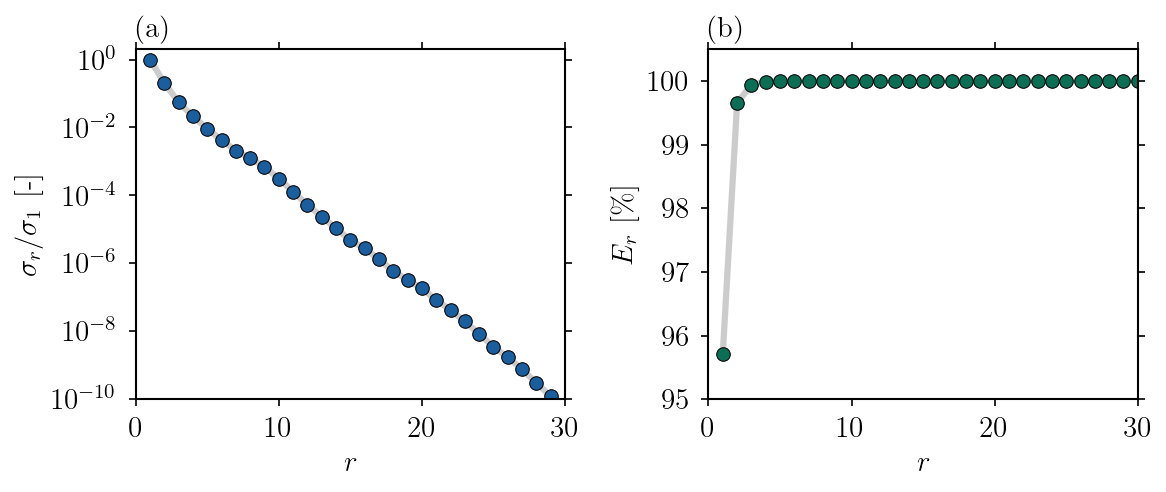

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# --- Plot (a): Singular Value Decay ---
ax = axes[0]
ax.semilogy(range(1, 31), sn[:30], 'o', color=C1, ms=6.5, mec='k', mew=0.5)
ax.semilogy(range(1, 31), sn[:30], color='gray', alpha=0.4, lw=3, zorder=1)

ax.set_title('(a)', loc='left', fontweight='normal')
ax.set_xlabel('$r$')
ax.set_ylabel(r'$\sigma_r / \sigma_1$ [-]')

ax.set_xlim([0, 30])
ax.set_ylim([1e-10, 2])

#ax.axvline(1, color='C3', ls=':', lw=1.5)
#ax.axvline(2, color='C0', ls=':', lw=1.5)
#ax.axvline(3, color='C5', ls=':', lw=1.5)

#ax.text(1, 1e-5, '$i=1$', color='C3', rotation=90, ha='right', va='center', fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
#ax.text(2, 1e-5, '$i=2$', color='C0', rotation=90, ha='right', va='center', fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
#ax.text(3, 1e-5, '$i=3$', color='C5', rotation=90, ha='right', va='center', fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

# --- Plot (b): Cumulative Energy ---
ax2 = axes[1]
ax2.plot(range(1, 31), cum[:30], 'o', color=C2, ms=6.5, mec='k', mew=0.5)
ax2.plot(range(1, 31), cum[:30], color='gray', alpha=0.4, lw=3, zorder=1)

ax2.set_title('(b)', loc='left', fontweight='normal')
ax2.set_xlabel('$r$')
ax2.set_ylabel(r'$E_r \ [\%]$')

ax2.set_xlim([0, 30])
ax2.set_ylim([95, 100.5])

#ax2.axhline(cum[0], color='C3', ls=':', lw=1.5)
#ax2.axhline(cum[1], color='C0', ls=':', lw=1.5)
#ax2.axhline(cum[2], color='C5', ls=':', lw=1.5)

#ax2.text(15, cum[0], f'$r=1 \ (E_r={cum[0]:.1f}\%)$', color='C3', ha='center', va='top', fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
#ax2.text(15, cum[1], f'$r=2 \ (E_r={cum[1]:.1f}\%)$', color='C0', ha='center', va='top', fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
#ax2.text(15, cum[2], f'$r=3 \ (E_r={cum[2]:.1f}\%)$', color='C5', ha='center', va='top', fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

plt.tight_layout()
sf('ch5_1_svd_rank_case1.pdf')
plt.show()

### 4.2 Figure 5 — POD Spatial Modes $\mathbf{u}_i(\mathbf{x})$

Each spatial mode $\mathbf{u}_i$ is a unit-norm vector in $\mathbb{R}^N$, reshaped to the grid $(n_y \times n_x)$. The sign convention follows the dominant sign in the near-well region. Mode 1 should show the radial pressure funnel; Mode 2 the PSS boundary correction.

  ch5_2_pod_modes_case1.pdf


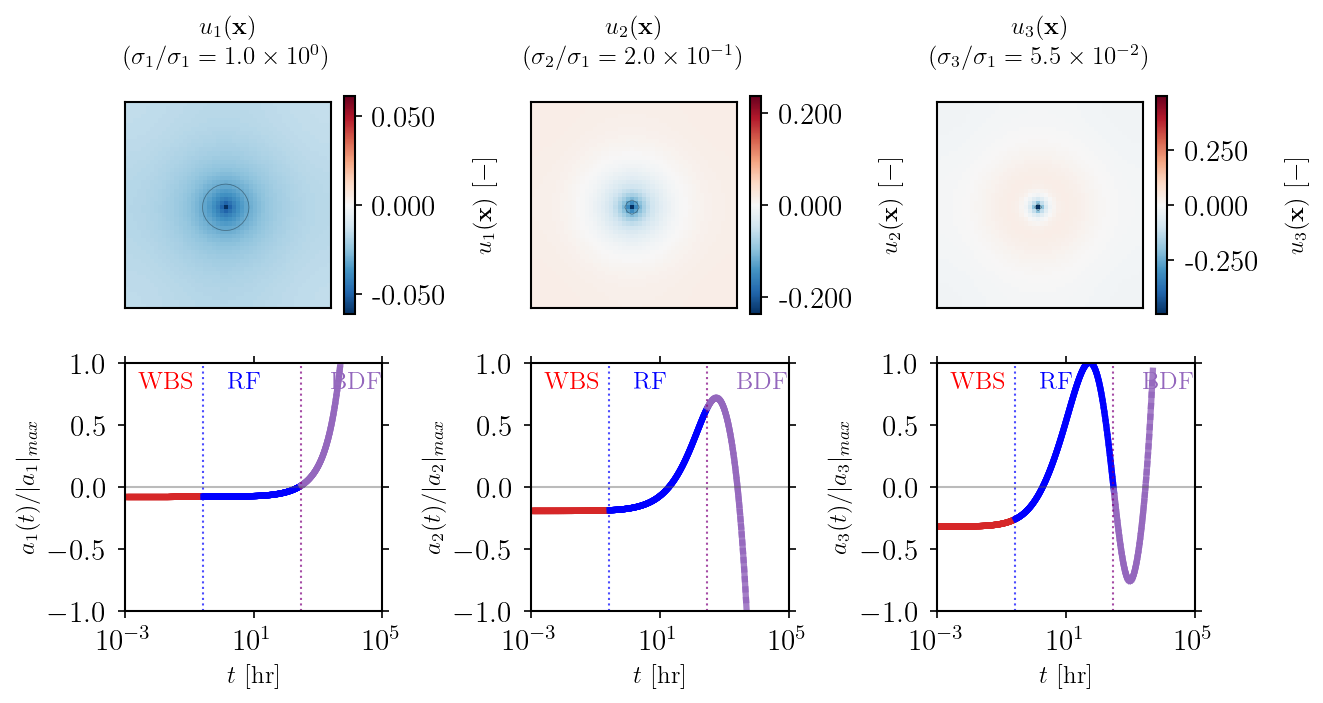

In [13]:
n_show = min(4, r_sel)
fig, axes = plt.subplots(2, n_show, figsize=(9, 5))
if n_show==1: axes=axes.reshape(2,1)

mode_phys = ['Radial drawdown\n(dominant depletion)',
             'PSS / boundary\ncorrection',
             'Near-well\ngradient',
             'Higher-order\nrefinement']

for i in range(n_show):
    # --- spatial mode ---
    ax = axes[0,i]
    ui = U[:,i].reshape(ny,nx)
    vm = np.abs(ui).max()
    im = ax.imshow(ui, origin='lower', cmap='RdBu_r', vmin=-vm, vmax=vm, aspect='equal')
    m_val = f"{sn[i]:.1e}".split('e')[0]
    e_val = int(f"{sn[i]:.1e}".split('e')[1])

    #ax.plot(nx//2,ny//2,'k+',ms=10,mew=2.5,zorder=10)
    ax.contour(np.abs(ui), levels=[vm*0.5], colors=['k'], linewidths=0.4, alpha=0.35)
    ax.set_title(f'${{u}}_{{{i+1}}}(\\mathbf{{x}})$\n'
                 f'$(\\sigma_{{{i+1}}}/\\sigma_1={m_val} \\times 10^{{{e_val}}})$\n',
                 fontsize=12)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    plt.colorbar(im,ax=ax,shrink=0.88,format='%.3f').set_label(rf'$u_{i+1}(\mathbf{{x}})\ [-]$', fontsize=12, rotation=90, labelpad=12)

    # --- temporal coefficient ---
    ax2 = axes[1,i]
    ai = sv[i]*Vt[i,:]                     # a_i(t) = σ_i * v_i(t)
    ai_n = ai/np.abs(ai).max()             # normalised for display
    
    # 1. Colors strictly matched to Case 3 (C3 for WBS, blue for RF, C4 for BDF)
    col_seg = ['C3' if ti < t_wbs else 'blue' if ti < t_pss else 'C4' for ti in t]
    
    for j in range(len(t)-1):
        ax2.semilogx(t[j:j+2], ai_n[j:j+2], color=col_seg[j], lw=3, alpha=0.85)
        
    # 2. Vertical lines matched to Case 3
    ax2.axvline(t_wbs, color='blue', lw=1.0, ls=':', alpha=0.7)
    ax2.axvline(t_pss, color='purple', lw=1.0, ls=':', alpha=0.7)
    
    ax2.axhline(0, color=GR, lw=1.0, alpha=0.4)
    ax2.set_xlabel('$t$ [hr]', fontsize=12)
    ax2.set_ylabel(f'$a_{i+1}(t)/|a_{i+1}|_{{max}}$', fontsize=12)
    ax2.set_xlim(0.001, 100000)
    ax2.set_ylim([-1, 1])
    
    # 3. Text colors strictly matched to Case 3
    ax2.text(0.05, 0.9, 'WBS', transform=ax2.transAxes, color='red', fontweight='normal', fontsize=12)
    ax2.text(0.40, 0.9, 'RF', transform=ax2.transAxes, color='blue', fontweight='normal', fontsize=12)
    ax2.text(0.80, 0.9, 'BDF', transform=ax2.transAxes, color='C4', fontweight='normal', fontsize=12)

plt.tight_layout()
#sf('fig5_homo_pod_modes_temporal.pdf')
sf('ch5_2_pod_modes_case1.pdf')
plt.show()

# 5 · Singular Spectrum Analysis for Flow Regime Identification

Conventional flow regime identification relies on visual inspection of the Bourdet derivative — a process that is subjective and noise-sensitive. This section introduces a **Singular Spectrum Analysis (SSA)** framework that produces two objective, time-resolved scalar metrics directly from the BHP log-derivative, without requiring any prior reservoir model.

---

## Method Overview

**Step 1 — Log-time resampling**  
The pressure drop $\Delta P = P_i - P_{wf}(t)$ is resampled onto a uniform grid in $\tau = \ln t$ (500 points) via cubic interpolation, and the log-derivative $\Delta P' = \partial \Delta P / \partial \ln t$ is computed by central finite differences. This is the signal fed into SSA.

**Step 2 — Hankel embedding**  
A $d \times (N-d)$ Hankel (trajectory) matrix $\mathbf{H}$ is built from the log-derivative signal with embedding dimension $d = 20$.

**Step 3 — Sliding SVD**  
A window of width $W = 30$ columns slides across $\mathbf{H}$. At each position $k$, the SVD $\mathbf{X}_k = \mathbf{U\Sigma V}^\top$ is computed, yielding a local singular value spectrum $\{\sigma_i^{(k)}\}$ centred at time $t_k$.

**Step 4 — Two scalar metrics**

$$R_k = \frac{\sum_{i=2}^{K} \sigma_i^2}{\sigma_1^2} \qquad \text{(Multi-Rank Complexity)}$$

$$H = -\sum_i p_i \ln p_i, \quad p_i = \frac{\sigma_i^2}{\sum_j \sigma_j^2} \qquad \text{(Spectral Entropy)}$$

---

## Physical Interpretation

| Metric | During WBS | During IARF | At BDF onset |
|--------|-----------|-------------|--------------|
| $R_k$  | Very low ($\sim 10^{-7}$) — rank-1 storage signal | Decays monotonically → **minimum marks $t_\text{stable}$** | Sharp spike — boundary tripwire |
| $H$    | Near zero | Valley (low entropy = ordered signal) | Large spike |

- **$t_\text{stable} = \arg\min R_k$** — the time of most stable radial flow; optimal window for permeability and skin estimation.
- The **spike in $R_k$** at $t_\text{BDF}$ is an objective, quantitative boundary detection signal.
- The **entropy valley** in $H$ corroborates the $R_k$ pick independently.

---

*Parameters used: $d = 20$, $W = 30$, $K = 3$ secondary modes. Spectral entropy is lightly smoothed (Savitzky-Golay, window 31); $R_k$ is plotted raw.*

  ch6_1_ssa_case1.pdf


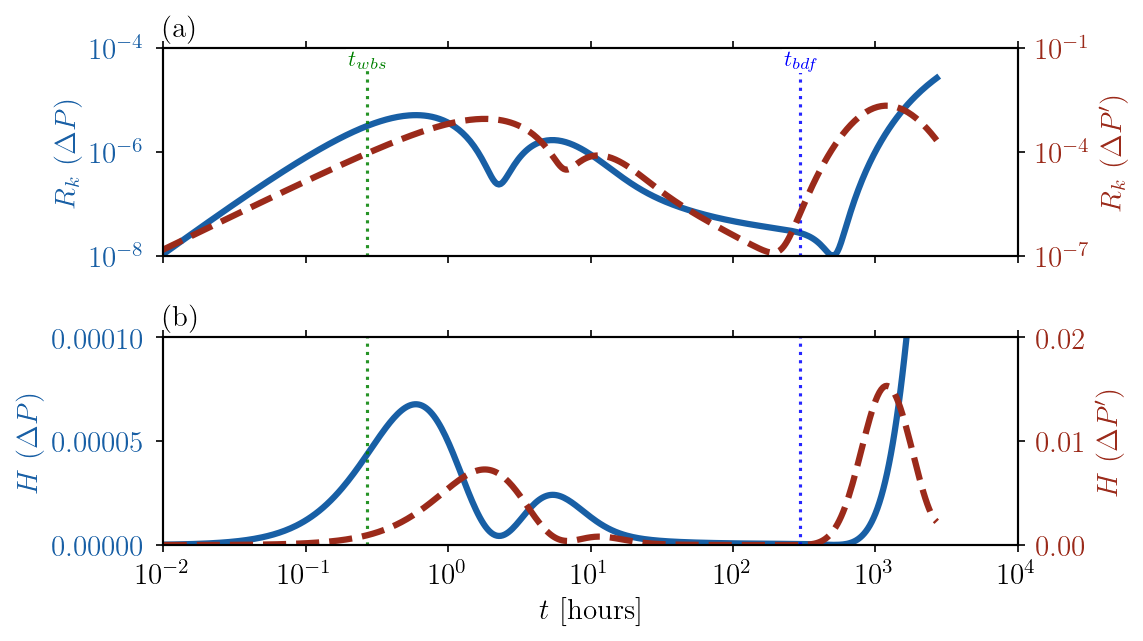

In [24]:
# =============================================================================
# SECTION 1: UNIFORM LOG-TIME RESAMPLING
# =============================================================================
dp_bhp   = P['p_init_psia'] - bhp
tau      = np.log(t)
tau_uni  = np.linspace(tau.min(), tau.max(), 500)
t_uni    = np.exp(tau_uni)

f_interp = interp1d(tau, dp_bhp, kind='cubic')
dp_uni   = f_interp(tau_uni)
dpr_uni  = np.gradient(dp_uni, tau_uni)

# =============================================================================
# SECTION 2: HANKEL EMBEDDING — built for both signals
# =============================================================================
def _build_hankel(signal, d):
    n = len(signal)
    H = np.zeros((d, n - d))
    for i in range(d):
        H[i, :] = signal[i : n - d + i]
    return H

d_h    = 20
W_h    = 40
k_rank = 3

H_dp  = _build_hankel(dp_uni,  d_h)   # from ΔP
H_dpr = _build_hankel(dpr_uni, d_h)   # from ΔP'

m_Hank = H_dp.shape[1]                # 500 - d_h = 480
t_Hank = t_uni[d_h:]                  # exactly m_Hank entries

# =============================================================================
# SECTION 3: SLIDING SSA — runs for both Hankel matrices
# =============================================================================
def _sliding_ssa(H_mat, t_Hank, W_h, k_rank):
    m      = H_mat.shape[1]
    n_h    = m - W_h
    t_str  = np.zeros(n_h)
    Rk     = np.zeros(n_h)
    H_ent  = np.zeros(n_h)

    for k_s in range(n_h):
        Xw          = H_mat[:, k_s : k_s + W_h]
        t_str[k_s]  = t_Hank[k_s + W_h // 2]

        try:
            _, S_w, _       = np.linalg.svd(Xw, full_matrices=False)
            energies        = S_w ** 2
            E_primary       = energies[0]

            Rk[k_s]         = np.sum(energies[1:k_rank]) / E_primary

            e_trunc         = energies[energies > 1e-10 * E_primary]
            p_i             = e_trunc / e_trunc.sum()
            H_ent[k_s]      = -np.sum(p_i * np.log(p_i))

        except Exception:
            Rk[k_s]    = np.nan
            H_ent[k_s] = np.nan

    return t_str, Rk, H_ent

t_stream_dp,  Rk_dp,  H_dp_ent  = _sliding_ssa(H_dp,  t_Hank, W_h, k_rank)
t_stream_dpr, Rk_dpr, H_dpr_ent = _sliding_ssa(H_dpr, t_Hank, W_h, k_rank)

# =============================================================================
# SECTION 4: SMOOTHING
# =============================================================================
def _smooth(arr):
    valid = np.isfinite(arr)
    n     = valid.sum()
    win   = 31 if n > 31 else (n // 2) * 2 - 1
    out   = np.full(len(arr), np.nan)
    out[valid] = savgol_filter(arr[valid], window_length=win, polyorder=3)
    return out, valid

H_dp_smooth,  v_dp  = _smooth(H_dp_ent)
H_dpr_smooth, v_dpr = _smooth(H_dpr_ent)

# valid masks for Rk (raw, no smoothing)
vr_dp  = np.isfinite(Rk_dp)
vr_dpr = np.isfinite(Rk_dpr)

# Stable radial flow: minimum Rk for each signal
idx_dp  = np.argmin(Rk_dp[vr_dp])
idx_dpr = np.argmin(Rk_dpr[vr_dpr])
t_stable_dp  = t_stream_dp[vr_dp][idx_dp]
t_stable_dpr = t_stream_dpr[vr_dpr][idx_dpr]

# =============================================================================
# SECTION 5: PLOTTING
# =============================================================================
# Color palette
C_dp  = '#185FA5'   # blue  — ΔP
C_dpr = '#9b2a1a'   # red   — ΔP'

ref_events = [(t_wbs, 'green', r'$t_{wbs}$'),
              (t_pss, 'blue',  r'$t_{bdf}$')]

fig, axes = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
fig.subplots_adjust(hspace=0.08)

# --- (a) Multi-Rank Complexity Rk — twin y axes ---
ax1      = axes[0]
ax1_twin = ax1.twinx()

ax1.loglog     (t_stream_dp[vr_dp],   Rk_dp[vr_dp],   color=C_dp,  lw=3.0, label=r'$R_k$ ($\Delta P$)')
ax1_twin.loglog(t_stream_dpr[vr_dpr], Rk_dpr[vr_dpr], color=C_dpr, lw=3.0, label=r"$R_k$ ($\Delta P'$)", ls='--')

# t_stable markers
ax1.scatter     (t_stable_dp,  Rk_dp[vr_dp][idx_dp],   color=C_dp,  s=60, zorder=5, marker='v')
ax1_twin.scatter(t_stable_dpr, Rk_dpr[vr_dpr][idx_dpr], color=C_dpr, s=60, zorder=5, marker='v')

ax1.set_ylabel     (r'$R_k$  ($\Delta P$)',  color=C_dp)
ax1_twin.set_ylabel(r"$R_k$  ($\Delta P'$)", color=C_dpr)
ax1.tick_params(axis='y', labelcolor=C_dp)
ax1_twin.tick_params(axis='y', labelcolor=C_dpr)
ax1.set_ylim([1e-8, 1e-4])
ax1_twin.set_ylim([1e-7, 1e-1])
ax1.set_title('(a)', loc='left')
ax1.xaxis.set_minor_locator(NullLocator())
ax1.yaxis.set_minor_locator(NullLocator())
ax1_twin.yaxis.set_minor_locator(NullLocator())
# combined legend
lines  = ax1.get_lines()      + ax1_twin.get_lines()
labels = [l.get_label() for l in lines]
#ax1.legend(lines, labels, fontsize=11, framealpha=0.4, loc='upper left')

# --- (b) Spectral Entropy H — twin y axes ---
ax2      = axes[1]
ax2_twin = ax2.twinx()

ax2.semilogx     (t_stream_dp[v_dp],   H_dp_smooth[v_dp],   color=C_dp,  lw=3.0, label=r'$H$ ($\Delta P$)')
ax2_twin.semilogx(t_stream_dpr[v_dpr], H_dpr_smooth[v_dpr], color=C_dpr, lw=3.0, label=r"$H$ ($\Delta P'$)", ls='--')

ax2.set_ylabel     (r'$H$  ($\Delta P$)',  color=C_dp)
ax2_twin.set_ylabel(r"$H$  ($\Delta P'$)", color=C_dpr)
ax2.tick_params(axis='y', labelcolor=C_dp)
ax2_twin.tick_params(axis='y', labelcolor=C_dpr)
ax2.set_xlabel(r'$t$  [hours]')
ax2.set_title('(b)', loc='left')
ax2.set_ylim([0, 0.0001])
ax2_twin.set_ylim([0, 0.02])
ax2.xaxis.set_minor_locator(NullLocator())
ax2.yaxis.set_minor_locator(NullLocator())

lines2  = ax2.get_lines()      + ax2_twin.get_lines()
labels2 = [l.get_label() for l in lines2]
#ax2.legend(lines2, labels2, fontsize=11, framealpha=0.4, loc='upper left')

# --- shared decorations ---
for ax_s in [ax1, ax2]:
    for tv, col, _ in ref_events:
        ax_s.axvline(tv, color=col, lw=1.5, ls=':', alpha=0.85)

for tv, col, lbl in ref_events:
    ax1.text(tv, 0.92, lbl,
             transform  = ax1.get_xaxis_transform(),
             fontsize=11, ha='center', color=col, fontweight='normal',
             bbox=dict(facecolor='white', edgecolor='none', pad=1.0))

ax1.set_xlim([0.01, 1e4])

plt.tight_layout()
#sf('fig6_homo_ssa.pdf')
sf('ch6_1_ssa_case1.pdf')
plt.show()

## 6 · Reduced-Order Model (ROM) Reconstruction

The ROM is based on the **Proper Orthogonal Decomposition** (POD) truncated reconstruction.
From the SVD $\mathbf{X}_c = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$, the rank-$r$
optimal approximation is given by the **Eckart–Young theorem**:

$$\hat{\mathbf{X}} = \mathbf{U}_r\,\boldsymbol{\Sigma}_r\,\mathbf{V}_r^T + \bar{\mathbf{x}}\mathbf{1}^T$$

where $\mathbf{U}_r \in \mathbb{R}^{N \times r}$ are the dominant spatial modes,
$\boldsymbol{\Sigma}_r = \mathrm{diag}(\sigma_1,\ldots,\sigma_r)$ the leading singular values,
and $\mathbf{V}_r^T \in \mathbb{R}^{r \times m}$ the corresponding temporal coefficients.
This is the **best rank-$r$ approximation** of $\mathbf{X}$ in the Frobenius norm —
no other rank-$r$ matrix achieves a smaller reconstruction error.

The selected rank $r$ satisfies the 99.9% energy threshold:

$$r = \min\left\{s \;\Big|\; E_s = \frac{\sum_{i=1}^s \sigma_i^2}{\sum_{i=1}^{\min(N,m)} \sigma_i^2} \geq 0.999\right\}$$

The global reconstruction error is exactly the energy in the discarded modes:

$$\varepsilon_G = \frac{\|\mathbf{X} - \hat{\mathbf{X}}\|_F}{\|\mathbf{X}\|_F}\times 100\%
= \frac{\sqrt{\sum_{i=r+1}^{\min(N,m)}\sigma_i^2}}{\|\boldsymbol{\Sigma}\|_F}\times 100\%$$

The ROM BHP at the well cell $i_w$ (zero-indexed) is:

$$\hat{p}_{wf,k} = \hat{\mathbf{X}}[i_w,\,k], \qquad k = 0,1,\ldots,m-1$$

POD truncation (not DMD, which requires uniform timesteps and is unstable on log-spaced PTA data) is used as the ROM.truction.

In [16]:
X_rom = U[:, :r_sel] @ np.diag(sv[:r_sel]) @ Vt[:r_sel, :] + X_mean

bhp_rom  = X_rom[wc, :]
dp_rom   = P['p_init_psia'] - bhp_rom
dpr_rom  = bourdet(np.clip(dp_rom, 0, None), t)

eps_t = (np.linalg.norm(X - X_rom, axis=0) /
         np.linalg.norm(X,          axis=0) * 100)
eps_g =  np.linalg.norm(X - X_rom, 'fro') / np.linalg.norm(X, 'fro') * 100

print(f'ROM rank r            : {r_sel}')
print(f'Global L² error ε_G   : {eps_g:.2f}%')
print(f'Max per-step error    : {eps_t.max():.2f}%')
print(f'Mean per-step error   : {eps_t.mean():.2f}%')
print(f'BHP ROM range         : {bhp_rom.min():.1f} – {bhp_rom.max():.1f} psia')
print(f'(global error = POD truncation error: 100×sqrt(Σσ²_r+1/Σσ²_all))')

ROM rank r            : 3
Global L² error ε_G   : 0.01%
Max per-step error    : 0.02%
Mean per-step error   : 0.01%
BHP ROM range         : 4125.0 – 4486.7 psia
(global error = POD truncation error: 100×sqrt(Σσ²_r+1/Σσ²_all))


### ROM Reconstruction Quality vs Rank — BHP and Bourdet derivative plots

The POD reconstruction $\hat{\mathbf{X}} = \mathbf{U}_r\boldsymbol{\Sigma}_r\mathbf{V}_r^T + \bar{\mathbf{x}}\mathbf{1}^T$
is evaluated at three ranks $r \in \{3, 5, 10\}$ to demonstrate how additional
modes progressively reduce the well-cell reconstruction error.

The global error bound from the Eckart–Young theorem is:

$$\varepsilon_G(r) = \frac{\sqrt{\sum_{i=r+1}^{\min(N,m)}\sigma_i^2}}{\|\mathbf{X}\|_F}\times 100\%$$

At the **well cell**, the local error is larger than $\varepsilon_G$ because the
near-well pressure gradient is the steepest feature in the field and requires
more modes to represent accurately. The plot shows how increasing $r$ closes the
gap between the ROM and the simulator, particularly in the radial flow region
where the logarithmic pressure increase demands smooth temporal representation.

### ROM Reconstruction Quality vs Rank — Well-Block Pressure

The POD reconstruction $\hat{\mathbf{X}} = \mathbf{U}_r\boldsymbol{\Sigma}_r\mathbf{V}_r^T + \bar{\mathbf{x}}\mathbf{1}^T$
is evaluated at three ranks $r \in \{3, 5, 10\}$ to demonstrate how additional
modes progressively reduce the well-cell reconstruction error.

The global error bound from the Eckart–Young theorem is:

$$\varepsilon_G(r) = \frac{\sqrt{\sum_{i=r+1}^{\min(N,m)}\sigma_i^2}}{\|\mathbf{X}\|_F}\times 100\%$$

---

#### What is the well cell?

In the MRST Cartesian grid, the reservoir is discretised into $N = n_x \times n_y$
rectangular cells. The **well cell** $i_w$ is the single grid cell whose centre
coincides with the wellbore location — in this simulation the central cell of
the $50 \times 50$ grid. Its MATLAB index is $i_w = (n_y/2 - 1)\,n_x + n_x/2 = 1225$,
converted to the Python zero-based index $i_w = 1224$.

The simulator reports two distinct pressures associated with the well:

| Quantity | Symbol | Source | Meaning |
|----------|--------|--------|---------|
| Grid-cell pressure | $p_{cell}(t)$ | `X[wc, :]` | Reservoir pressure averaged over the well block volume |
| Wellbore BHP | $p_{wf}(t)$ | `bhp` from `wellSol` | Flowing pressure at the sandface, after Peaceman + skin correction |

The ROM reconstructs the **grid-cell pressure** $p_{cell}$, not the wellbore BHP.
The two differ by the combined Peaceman and skin pressure drop:

$$p_{cell} - p_{wf} = \frac{141.2\,q\mu B_o}{kh}
\!\left(\ln\frac{r_{eq}}{r_w} + S\right) \approx 313 \text{ psia}$$

where $r_{eq} = 0.2\,\Delta x = 19.7$ ft is the Peaceman equivalent radius for
the 30 m grid cell. The well cell is the **most demanding cell to reconstruct**
because it contains the steepest pressure gradient in the entire field — the
near-well drawdown funnel is spatially concentrated here, requiring more POD
modes to represent accurately than the smooth far-field region.

---

#### What do the error percentages indicate?

Two error metrics are reported for each rank $r$:

**Global Frobenius error $\varepsilon_G$** measures the reconstruction accuracy
averaged over the entire pressure field — all $N = 2500$ cells and all $m$
timesteps simultaneously:

$$\varepsilon_G(r) = \frac{\|\mathbf{X} - \hat{\mathbf{X}}\|_F}{\|\mathbf{X}\|_F}
\times 100\%$$

A value of $\varepsilon_G = 0.01\%$ means the ROM reproduces the full
spatio-temporal pressure field to within one part in ten thousand, on average
across all cells and all times. This metric is dominated by the many far-field
cells that change very little and are trivially well-reconstructed.

**Well-cell local error $\varepsilon_{well}$** measures the reconstruction
accuracy specifically at the well cell over the plotted time window:

$$\varepsilon_{well}(r) = \frac{\|\,p_{cell}(t) - \hat{p}_{cell}(t)\,\|_2}
{\|\,p_{cell}(t)\,\|_2} \times 100\%$$

This metric is always larger than $\varepsilon_G$ because the well cell carries
the largest pressure variation in the field. The gap between $\varepsilon_G$ and
$\varepsilon_{well}$ directly quantifies how much harder the near-well region is
to reconstruct relative to the global average. As $r$ increases, $\varepsilon_{well}$
decreases faster than $\varepsilon_G$, because the additional modes specifically
capture the residual near-well spatial structure that low-rank truncation misses.

For PTA purposes, $\varepsilon_{well}$ is the operationally relevant metric:
the Bourdet derivative and $kh$ estimation depend entirely on the well-cell
pressure trajectory, so a small $\varepsilon_G$ with a large $\varepsilon_{well}$
would still produce an inaccurate PTA diagnostic.

  ch5_3_pwf_dp_recon_case1.pdf


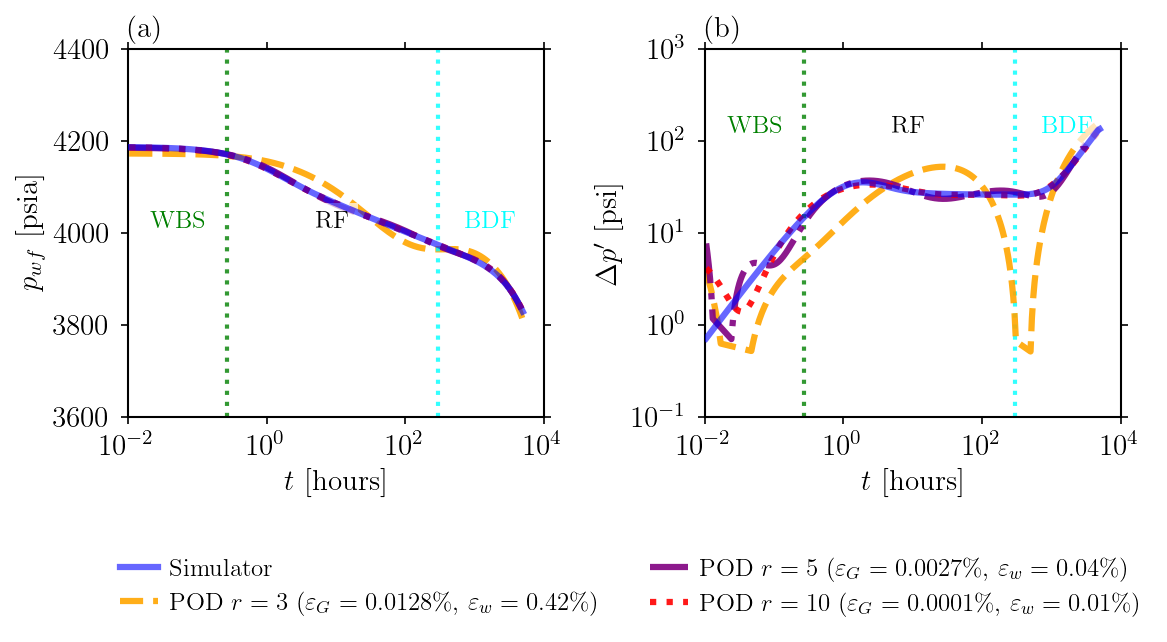


   r           ε_G        ε_well     max|err| [psia]
────────────────────────────────────────────────────
   3       0.0128%        0.415%             33.54
   5       0.0027%        0.039%              2.91
  10       0.0001%        0.009%              0.83


In [18]:
# ── Peaceman + skin correction ─────────────────────────────────────────────
r_eq_ft       = 0.2 * P['dx_ft']
dp_correction = (141.2 * P['q_STBd'] * P['mu_cp'] * P['Bo'] / P['kh_mDft']
                 * (np.log(r_eq_ft / P['rw_ft']) + P['S_skin']))

ranks  = [3, 5, 10]
colors = ['orange', 'purple', 'red']
styles = ['--', '-.', ':']

t_lo, t_hi = 1e-2, 1e4
t_mask = (t >= t_lo) & (t <= t_hi)
lnt    = np.log(t)

# ── simulator ─────────────────────────────────────────────────────────────
bhp_sim = bhp
dp_sim  = P['p_init_psia'] - bhp_sim
dpr_sim = bourdet(np.clip(dp_sim, 0, None), t, L=0.2)
vs_sim  = t_mask & (dp_sim > 0.5) & (dpr_sim > 0.5)

# ── ROM quantities for all ranks ───────────────────────────────────────────
rom_data = {}
for r in ranks:
    X_r      = U[:, :r] @ np.diag(sv[:r]) @ Vt[:r, :] + X_mean
    bhp_r_wf = X_r[wc, :] - dp_correction
    dp_r     = P['p_init_psia'] - bhp_r_wf

    vf      = t_mask & (dp_r > 0.5) & np.isfinite(dp_r)
    spl     = UnivariateSpline(lnt[vf], dp_r[vf], k=5, s=vf.sum() * 0.3)
    dp_spl  = np.clip(spl(lnt),              0, None)
    dpr_spl = np.clip(spl.derivative()(lnt), 0, None)
    vs_r    = t_mask & (dp_spl > 0.5) & (dpr_spl > 0.5)

    eps_g_r   = (np.linalg.norm(X - X_r, 'fro') /
                 np.linalg.norm(X, 'fro') * 100)
    eps_local = (np.linalg.norm(bhp_sim[t_mask] - bhp_r_wf[t_mask]) /
                 np.linalg.norm(bhp_sim[t_mask]) * 100)

    rom_data[r] = dict(bhp_wf=bhp_r_wf, dp_spl=dp_spl, dpr_spl=dpr_spl,
                       vs=vs_r, eg=eps_g_r, el=eps_local)

# ── regime label x-positions (computed from log-axis fractions) ────────────
log_lo    = np.log10(t_lo)
log_range = np.log10(t_hi) - log_lo

def xpos(t_val):
    return (np.log10(np.clip(t_val, t_lo, t_hi)) - log_lo) / log_range

wbs_x = xpos(np.sqrt(t_lo * t_wbs))
rf_x  = xpos(np.sqrt(t_wbs * t_pss))
bdf_x = xpos(np.sqrt(t_pss * t_hi))

# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# ── panel (a): BHP ────────────────────────────────────────────────────────
ax = axes[0]

ax.semilogx(t[t_mask], bhp_sim[t_mask],
            color='blue', alpha=0.6, lw=3.0, label='Simulator', zorder=4)

for r, col, ls in zip(ranks, colors, styles):
    d = rom_data[r]
    ax.semilogx(t[t_mask], d['bhp_wf'][t_mask],
                color=col, lw=3.0, ls=ls, alpha=0.90,
                label=(rf'POD  $r={r}$  '
                       rf'($\varepsilon_G={d["eg"]:.4f}\%$, '
                       rf'$\varepsilon_{{w}}={d["el"]:.2f}\%$)'))

ax.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.8)
ax.axvline(t_pss, color='cyan',  lw=2, ls=':', alpha=0.8)

for xp, lbl, color_name in [(wbs_x, 'WBS', 'green'), (rf_x, 'RF', 'black'), (bdf_x, 'BDF', 'cyan')]:
    ax.text(xp, 0.56, lbl, transform=ax.transAxes, fontsize=12,
            color=color_name, ha='center', verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_title('(a)', loc='left', weight='normal')
ax.set_xlabel('$t$ [hours]')
ax.set_ylabel('$p_{wf}$ [psia]')
ax.set_xlim([t_lo, t_hi])
ax.set_ylim([3600, 4400])
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())
# NOTE: ax.legend() removed from here

# ── panel (b): Bourdet derivative Δp' only ────────────────────────────────
ax2 = axes[1]

ax2.axvline(t_wbs, color='green', lw=2, ls=':', alpha=0.8)
ax2.axvline(t_pss, color='cyan',  lw=2, ls=':', alpha=0.8)

ax2.loglog(t[vs_sim], dpr_sim[vs_sim],
           color='blue', alpha=0.6, lw=3.0, label='Simulator', zorder=4)

for r, col, ls in zip(ranks, colors, styles):
    d = rom_data[r]
    ax2.loglog(t[d['vs']], d['dpr_spl'][d['vs']],
               ls, color=col, lw=3.0, alpha=0.90,
               label=rf'POD  $r={r}$')

mtr_flat = t_mask & (t > t_wbs) & (t < t_pss)

for xp, lbl, color_name in [(wbs_x, 'WBS', 'green'), (rf_x, 'RF', 'black'), (bdf_x, 'BDF', 'cyan')]:
    ax2.text(xp, 0.82, lbl, transform=ax2.transAxes, fontsize=12,
             color=color_name, ha='center', verticalalignment='top',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax2.set_title('(b)', loc='left', weight='normal')
ax2.set_xlabel('$t$ [hours]')
ax2.set_ylabel(r"$\Delta p'$ [psi]")
ax2.set_xlim([1e-2, 1e4])
ax2.set_ylim([0.1, 1000])
ax2.xaxis.set_minor_locator(NullLocator())
ax2.yaxis.set_minor_locator(NullLocator())

# ── Figure-Level Legend ───────────────────────────────────────────────────
# Extract handles and labels from panel (a)
handles, labels = ax.get_legend_handles_labels()

# Place the legend at the bottom center of the figure, spanning 2 columns
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 0.0), 
           ncol=2, framealpha=0.0, fontsize=12)

# Adjust layout to leave the bottom 25% empty for the legend
plt.tight_layout(rect=[0.01, 0.01, 1, 1.05])

#sf('fig8_rom_rank_comparison.pdf')
sf('ch5_3_pwf_dp_recon_case1.pdf')
plt.show()

# ── printed summary ────────────────────────────────────────────────────────
print(f'\n{"r":>4}  {"ε_G":>12}  {"ε_well":>12}  {"max|err| [psia]":>18}')
print('─' * 52)
for r in ranks:
    d  = rom_data[r]
    mx = np.abs(bhp_sim[t_mask] - d['bhp_wf'][t_mask]).max()
    print(f'{r:4d}  {d["eg"]:>11.4f}%  {d["el"]:>11.3f}%  {mx:>16.2f}')

### 6.2 Figure 9 — ROM Reconstruction Error Over Time

The per-timestep relative $L^2$ error $\varepsilon_k = \|\mathbf{x}_k - \hat{\mathbf{x}}_k\|_2 / \|\mathbf{x}_k\|_2 \times 100\%$ is expected to be small during radial flow (where Mode 1 dominates) and may increase slightly at the regime transition where Mode 2 (PSS correction) becomes important.

---
## 7 · Ground Truth vs ROM: Spatial Field Comparison

The reconstruction is evaluated separately in the **transient (radial flow)** and **PSS (BDF)** regimes to expose where the ROM is accurate and where it may need additional modes. For each regime, two representative snapshot times are selected and three images are shown side-by-side:

- **Ground truth** $\Delta p(\mathbf{x},t)$ from the full MRST simulation
- **ROM** $\hat{\Delta p}(\mathbf{x},t)$ reconstructed with $r$ modes
- **Residual** $\Delta p - \hat{\Delta p}$ on a symmetric colour scale

  fig11_RF_Reconstruction_Matrix.pdf


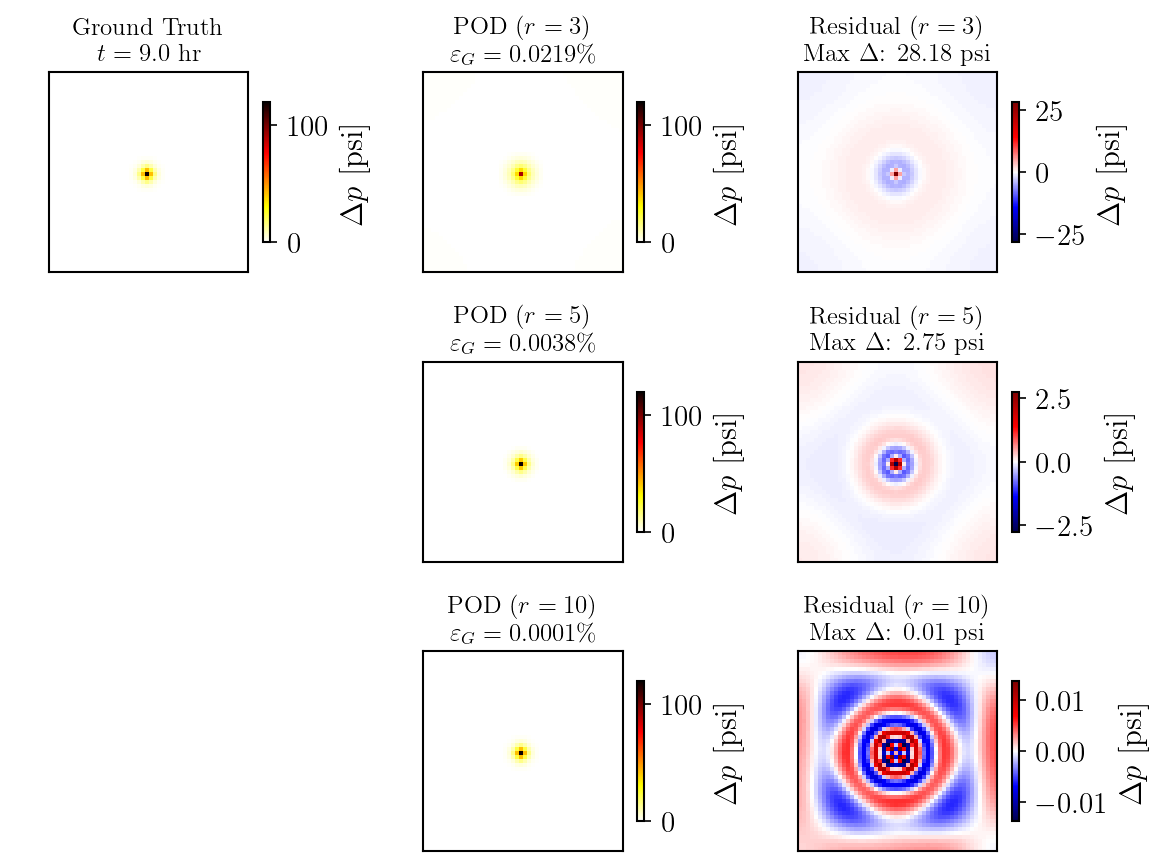

In [22]:
n_ranks = len(ranks)

fig, axes = plt.subplots(n_ranks, 3, figsize=(8, 6))

# Pre-calculate Ground Truth
ki = int(np.argmin(np.abs(t - t_rf_snap)))
F_gt = dX[:, ki].reshape(ny, nx)
vm = max(F_gt.max(), 0.1)

for ri, r in enumerate(ranks):
    # Data Calculations
    X_r = U[:, :r] @ np.diag(sv[:r]) @ Vt[:r, :] + X_mean
    dX_r = (P['p_init_psia'] - X_r)[:, ki].reshape(ny, nx)
    diff = F_gt - dX_r
    eps_step = (np.linalg.norm(X[:,ki] - X_r[:,ki]) / np.linalg.norm(X[:,ki]) * 100)
    vd = max(np.abs(diff).max(), 0.01)

    # Column 0: Ground Truth (Only plot in the very first top-left cell)
    ax_gt = axes[ri, 0]
    if ri == 0:
        im1 = ax_gt.imshow(F_gt, origin='lower', cmap='hot_r', vmin=0, vmax=vm)
        ax_gt.set_title(rf'Ground Truth' + '\n' + rf'$t={t[ki]:.1f}$ hr', fontweight='normal', fontsize=12)
        #ax_gt.plot(nx // 2, ny // 2, 'w+', ms=7, mew=1.5)
        fig.colorbar(im1, ax=ax_gt, shrink=0.7).set_label(r'$\Delta p$ [psi]', size=15)
    else:
        # Hide the slots in the GT column for other rows to keep the 1,1 position unique
        ax_gt.axis('off')

    # Column 1: POD Reconstruction
    ax_pod = axes[ri, 1]
    im2 = ax_pod.imshow(dX_r, origin='lower', cmap='hot_r', vmin=0, vmax=vm)
    ax_pod.set_title(rf'POD ($r={r}$)' + '\n' + rf'$\varepsilon_G={eps_step:.4f}\%$', fontweight='normal', fontsize=12)
    #ax_pod.plot(nx // 2, ny // 2, 'w+', ms=7, mew=1.5)
    fig.colorbar(im2, ax=ax_pod, shrink=0.7).set_label(r'$\Delta p$ [psi]', size=15)

    # Column 2: Residuals
    ax_res = axes[ri, 2]
    im3 = ax_res.imshow(diff, origin='lower', cmap='seismic', vmin=-vd, vmax=vd)
    ax_res.set_title(rf'Residual ($r={r}$)' + '\n' + rf'Max $\Delta$: {vd:.2f} psi', fontweight='normal', fontsize=12)
    #ax_res.plot(nx // 2, ny // 2, 'k+', ms=7, mew=1.5)
    fig.colorbar(im3, ax=ax_res, shrink=0.7).set_label(r'$\Delta p$ [psi]', size=15)

    for ax_obj in [ax_gt, ax_pod, ax_res]:
        if ax_obj.axison: # Only format if not hidden
            ax_obj.set_xticks([]); ax_obj.set_yticks([])

#fig.suptitle(f'Spatial Modal Reconstruction Accuracy: Radial Flow Regime', 
             #fontsize=12, fontweight='normal', y=0.98)

plt.tight_layout()
sf('ch5_4_p_field_recon_case1.pdf')
plt.show()

---
## 8 · Summary of Results

| Quantity | Simulator | ROM | Theory | Error |
|----------|-----------|-----|--------|-------|
| Bourdet flat $\Delta p'$ [psi] | `flat_sim` | `flat_rom_val` | `dp_flat` | — |
| $kh$ [mD-ft] | `kh_est` | — | `kh` | — |
| POD rank $r_{99.9\%}$ | — | `r999` | — | — |
| Global $L^2$ error $\varepsilon_G$ | — | `eps_g`% | — | — |

In [23]:
# ── known parameters ──────────────────────────────────────────────────────
h_ft  = P['h_ft']
phi_  = P['phi']
ct    = P['ct_psi1']
mu    = P['mu_cp']
Bo    = P['Bo']
rw    = P['rw_ft']
q     = P['q_STBd']
kh_true = P['kh_mDft']
k_true  = P['k_mD']
S_true  = P['S_skin']

r_eq_ft       = 0.2 * P['dx_ft']
dp_correction = (141.2 * q * mu * Bo / kh_true
                 * (np.log(r_eq_ft / rw) + S_true))

# ── helper: extract k and S from a BHP time series ────────────────────────
def characterise(dp_arr, t_arr, mtr_m, vs_m, label):
    """
    dp_arr  : drawdown array [psi]
    t_arr   : time array [hr]
    mtr_m   : boolean mask for MTR window
    vs_m    : valid Bourdet mask
    """
    # ── 1. Bourdet derivative -> kh ───────────────────────────────────────
    dpr_arr   = bourdet(np.clip(dp_arr, 0, None), t_arr, L=0.2)
    flat_val  = np.median(dpr_arr[mtr_m & vs_m & (dpr_arr > 0)])
    kh_calc   = 70.6 * q * mu * Bo / flat_val
    k_calc    = kh_calc / h_ft

    # ── 2. MTR semilog slope -> independent kh check ─────────────────────
    cf_r      = np.polyfit(np.log10(t_arr[mtr_m]), dp_arr[mtr_m], 1)
    m_calc    = cf_r[0]                             # psi/cycle
    kh_slope  = 162.6 * q * mu * Bo / m_calc
    k_slope   = kh_slope / h_ft

    # ── 3. Skin from 1-hour drawdown ─────────────────────────────────────
    dp_1hr    = float(np.interp(1.0, t_arr, dp_arr))
    S_calc    = 1.1513 * (dp_1hr / m_calc
                          - np.log10(k_calc / (phi_ * mu * ct * rw**2))
                          + 3.2275)

    return dict(label=label,
                flat=flat_val, kh_bourdet=kh_calc, k_bourdet=k_calc,
                m_slope=m_calc, kh_slope=kh_slope, k_slope=k_slope,
                dp_1hr=dp_1hr, S=S_calc)

# ── ground truth (simulator wellbore BHP) ─────────────────────────────────
res_sim = characterise(dp, t, mtr_mask, vs, 'Simulator (GT)')

# ── ROM at each rank ──────────────────────────────────────────────────────
results = [res_sim]
for r in ranks:
    X_r      = U[:, :r] @ np.diag(sv[:r]) @ Vt[:r, :] + X_mean
    bhp_r_wf = X_r[wc, :] - dp_correction
    dp_r     = P['p_init_psia'] - bhp_r_wf
    dpr_r    = bourdet(np.clip(dp_r, 0, None), t, L=0.2)
    vs_r     = mtr_mask & (dpr_r > 1e-2) & (dp_r > 1e-2)
    res_r    = characterise(dp_r, t, mtr_mask, vs_r, f'ROM  r={r}')
    results.append(res_r)

# ── print table ───────────────────────────────────────────────────────────
W = 14

print('=' * 90)
print(' RESERVOIR CHARACTERISATION — ROM vs GROUND TRUTH')
print('=' * 90)

# header
print(f'\n{"":20s} '
      f'{"True":>{W}} '
      f'{"Simulator":>{W}} '
      f'{"ROM r=3":>{W}} '
      f'{"ROM r=5":>{W}} '
      f'{"ROM r=10":>{W}}')
print('-' * 90)

def row(label, key, fmt, true_val):
    vals = [res[key] for res in results]
    line = f'{label:<20s} {true_val:>{W}{fmt}} '
    for v in vals:
        line += f'{v:>{W}{fmt}} '
    print(line)

def row_err(label, key, true_val):
    vals = [res[key] for res in results]
    line = f'{label:<20s} {"—":>{W}} '
    for v in vals:
        err = (v - true_val) / abs(true_val) * 100
        line += f'{err:>{W}.2f} '
    print(line)

# ── Bourdet flat level
print(f'\n  — PERMEABILITY from Bourdet flat  Δp′_flat = 70.6·q·μ·Bo / kh —')
row("Δp′_flat  [psi]",  'flat',       '.4f', dp_flat)
row("kh (Bourdet) [mD-ft]", 'kh_bourdet', '.2f', kh_true)
row("k  (Bourdet) [mD]",    'k_bourdet',  '.3f', k_true)
row_err("  kh error [%]",   'kh_bourdet',          kh_true)
row_err("  k  error [%]",   'k_bourdet',            k_true)

# ── MTR semilog slope
print(f'\n  — PERMEABILITY from MTR semilog slope  kh = 162.6·q·μ·Bo / m —')
row("m_slope [psi/cycle]",  'm_slope',   '.4f', m_slope)
row("kh (slope) [mD-ft]",   'kh_slope',  '.2f', kh_true)
row("k  (slope) [mD]",      'k_slope',   '.3f', k_true)
row_err("  kh error [%]",   'kh_slope',           kh_true)
row_err("  k  error [%]",   'k_slope',             k_true)

# ── Skin
print(f'\n  — SKIN FACTOR from 1-hour drawdown —')
row("Δp at t=1 hr [psi]",   'dp_1hr',    '.3f', float(np.interp(1.0, t, dp)))
row("Skin S  [-]",           'S',          '.4f', S_true)
row_err("  S error [%]",     'S',                  S_true)

print('\n' + '=' * 90)
print(f'  True reservoir values:')
print(f'    k      = {k_true:.1f} mD   |   kh = {kh_true:.0f} mD-ft   |   '
      f'S = {S_true:.1f}   |   h = {h_ft:.1f} ft')
print(f'    φ = {phi_:.2f}   |   μ = {mu:.2f} cp   |   '
      f'cₜ = {ct:.2e} psi⁻¹   |   rw = {rw:.3f} ft')
print('=' * 90)

 RESERVOIR CHARACTERISATION — ROM vs GROUND TRUTH

                               True      Simulator        ROM r=3        ROM r=5       ROM r=10
------------------------------------------------------------------------------------------

  — PERMEABILITY from Bourdet flat  Δp′_flat = 70.6·q·μ·Bo / kh —
Δp′_flat  [psi]             25.9808        26.9167        28.5689        28.6926        26.7957 
kh (Bourdet) [mD-ft]        3000.00        2895.69        2728.23        2716.46        2908.77 
k  (Bourdet) [mD]            20.000         19.305         18.188         18.110         19.392 
  kh error [%]                    —          -3.48          -9.06          -9.45          -3.04 
  k  error [%]                    —          -3.48          -9.06          -9.45          -3.04 

  — PERMEABILITY from MTR semilog slope  kh = 162.6·q·μ·Bo / m —
m_slope [psi/cycle]         59.8368        67.2297        80.5337        67.7354        66.9781 
kh (slope) [mD-ft]          3000.00        2670